# 🦾 ⚙️🦿 The Engine Room: Weekly Squid CPUE Prediction  — End-to-End ML Workflow 
### Module 4 of the SquidStock Analytics Series*

### Classification • Class-Conditioned Regression • Feature Engineering • Anomaly Detection • Deployment

This notebook builds a complete machine-learning workflow to model **weekly CPUE (Catch-Per-Unit-Effort)** for short-lived squid species *(Illex argentinus)* in the South West Atlantic Ocean (SWAO) using only the first six months (Jan–Jun) of the dataset. It uses simulated data that resembles raw vessel‐day logbook data from Taiwan's jigging vessel fleet. 

Our focus is on **interpretation**, **feature engineering**, and **workflow structure**, not perfect predictive performance — because CPUE is noisy and influenced by multiple unobserved drivers.

**Learning Objectives and Project Framing:**  
- Understand and implement **AutoML pipelines** for both classification and regression tasks.  
- Apply **feature selection techniques** (e.g., Boruta) and explore **feature importance** to interpret drivers of CPUE.  
- Work with **real-world ecological data**, dealing with seasonal trends, environmental interactions, and noise.  
- Learn how to handle **anomalies, drift, and low-signal regimes**, and reflect these challenges in our modeling.  
- Develop the **end-to-end workflow**, including preprocessing, modeling, evaluation, and deployment readiness.  


---

# Executive Summary – CPUE Prediction Project

Both model types (Classification and Regression) indicate that predicting high CPUE weeks is the primary challenge, medium CPUE is moderately predictable, and low CPUE is relatively easier.

## 1. Classification Model Insights (CPUE Levels: Low, Medium, High)

- **Best Performing Model:** Random Forest Classifier  
- **Performance Highlights:**  
  - F1 scores ~0.53 for top model, with overall moderate accuracy (~51%)  
  - Confusion matrix shows low CPUE weeks are predicted most accurately, medium weeks moderately, and high CPUE weeks least accurately.  
- **Key Features:** Environmental and seasonal variables drive model decisions; redundant predictors were removed to reduce noise  
- **Interpretation:**  
  - Model effectively distinguishes extreme abundance weeks (Low vs High)  
  - Medium weeks are harder to classify due to overlapping environmental conditions  

**Practical Implication:** Operational teams can use predictions to anticipate peak or low fishing weeks. Medium weeks require caution as predictions are less certain.

---

## 2. Regression Model Insights (Log-Transformed CPUE)

- **Best Models by CPUE Level:**  
  - Low: LightGBM  
  - Medium: LightGBM  
  - High: Extra Trees Regressor  
- **Performance Highlights:**  
  - Low CPUE: MAE ≈ 2.98, RMSE ≈ 3.57, R² ≈ -0.71   
  - Medium CPUE: MAE ≈ 0.45, RMSE ≈ 0.50, R² ≈ -0.007 (high variability in data reduces reliability)  
  - High CPUE: MAE ≈ 0.25, RMSE ≈ 0.30, R² ≈ -1.15  
- **Key Features:** Depth, Latitude, Longitude, Temperature × Depth interactions, Week of Year (seasonality)  
- **Interpretation:**  
  - Low abundance weeks are moderately predictable  
  - Medium CPUE remains highly variable, reflecting unpredictable ecological factors 
  - Extreme peaks from high CPUE regime are still difficult to capture precisely

**Practical Implication:** Regression predictions help estimate expected catch volume, supporting effort planning and environmental risk assessment.

---

## 3. Anomaly Detection & Feature Drift

- **Feature Drift:** Some environmental and spatial features showed minor shifts between training and testing datasets  
- **Impact:** Minimal on overall model performance due to tree-based models’ robustness  
- **Anomalies Detected:** Roughly two-thirds of observations deviate from typical patterns. Anomalies highlight unusual environmental or operational conditions. This aligns with regression uncertainty, especially in Medium and High CPUE weeks.
  

**Practical Implication:** Teams can use anomaly flags to investigate unusual environmental or catch conditions that may require adaptive management.

---

## 4. Overall Recommendation:
  
- Use model predictions for planning and operational decision-making  
- Exercise caution in medium abundance weeks  
- Monitor anomalies and feature shifts to adapt strategies dynamically


---

# Machine Learning Workllow

## 1️⃣ Data Wrangling & Weekly Aggregation  
- Convert daily vessel log data into **weekly regional observations**.  
- Compute weekly catch, effort, and **weekly CPUE** per effort unit.  
- Restrict to **January–June** to ensure:  
  - consistent seasonal cycles  
  - reduced sparsity  
  - biologically meaningful periods for short-lived squid.

---

## 2️⃣ Feature Engineering (Biological + Operational Rationale)

### **A. Rolling Windows**  
Squid respond to short-term environmental changes.  
Because variables have **different temporal resolutions**:

- **WaterTemp, Depth** → frequent observations  
  → use **2-week and 3-week rolling averages**  
  → captures short-term persistence without over-smoothing  

- **Chlorophyll-a, SSH** → monthly satellite data  
  → use **5-week rolling averages**  
  → avoids fabricating sub-monthly resolution  
  → smooths monthly variability

This combination respects the *true temporal structure* of each dataset.

---

### **B. Seasonal Encoding (Sine/Cosine Transformation)**  
Squid show strong **seasonality**. To model circular time (week 1 ≈ week 52), we encode:

*sin_week = sin(2π * WeekOfYear / 52)*<br>
*cos_week = cos(2π * WeekOfYear / 52)*

This avoids artificial jumps (e.g., week 1 far from week 52 numerically) and supports smooth cyclic patterns.

### **C. Interaction Features** 
To capture ecological coupling:
- Temp × Depth  
- Temp × Chlorophyll  
- Depth × Chlorophyll
- Temp × SSH

These interactions reflect how squid aggregations depend on thermal structure + productivity + ocean circulation simultaneously.

### **D. Domain-Based Binning** 
Environmental features are discretized into interpretable ecological zones (shallow/mid/deep, cold/moderate/warm, etc.) to enhance interpretability and assist anomaly detection.

### **3️⃣ Feature Selection (Boruta)** 
Automated feature selection (Boruta) was attempted first, but due to the  
complexity and multicollinearity of ecological predictors, it retained too few  
features for meaningful modeling.  
To maintain scientific validity and predictive usefulness, a domain-guided  
manual selection process was adopted.

### **4️⃣ Classification Model — Predict Low / Medium / High CPUE** 
Instead of predicting raw CPUE directly, we classify each week into:
- Low CPUE  
- Medium CPUE 
- High CPUE
This stabilizes prediction because raw CPUE is long-tailed, zero-inflated, and sensitive to outliers.

### **5️⃣ Class-Conditioned Regression Models** 
Conditioned Regression Models
After classifying CPUE, we train three separate regressors, each specialized for its CPUE regime:
- Low-CPUE regressor
- Medium-CPUE regressor
- High-CPUE regressor<br>
This allows the model to learn different ecological dynamics in each abundance regime.

> **Model Choice Rationale:**  
> Tree-based models (Random Forest, LightGBM, Extra Trees) were chosen because:
> - They naturally handle **nonlinear relationships** and **feature interactions**, which are common in CPUE data.
> - They are robust to **outliers** and **missing values**, frequent in ecological datasets.
> - They provide **feature importance metrics**, which support ecological interpretation.
> - The regression target, **CPUE_log1p**, is log-transformed to stabilize variance and reduce skew, and tree-based models work well with such transformations.


### **6️⃣ Unsupervised Anomaly Detection** 
An Isolation Forest flags unusual environmental conditions or data points:
- anomalous vessel behaviour
- measurement inconsistencies
- rare biological events
- structurally unusual environmental combinations
Output:
1 = anomaly, 0 = normal


### **7️⃣ Deployment via Streamlit** 
All models (classifier, regressors, anomaly detector) are exported for an interactive app with:
- user-provided environmental inputs
- real-time CPUE class prediction
- real-time CPUE regression estimate
- anomaly flag
- feature importance & SHAP explanations
- Custom sidebar & main-panel background images


### **🌍 Real-World Applications** 
This workflow supports:
- **Fisheries management**
  - Detect early-season conditions linked to low catches
  - Predict potential high-abundance weeks for planning
  - Improve stock assessment inputs<br>

- **Ecological research**
  - Understand short-term squid responses to environmental variability
  - Identify environmental thresholds for squid aggregation<br>

- **Vessel operations**
  - Provide decision support (e.g., likely CPUE for planned fishing week)
  - Detect anomalous conditions that may require caution<br>

- **Climate/ocean monitoring**
  - Examine how seasonal cycles interact with productivity and ocean structure

### **⚠️ Current Limitations** 
   - The dataset is relatively small and noisy, which constrains the statistical power of the models.
   - CPUE is strongly influenced by unobserved ecological and behavioural variables (e.g., prey availability, mesoscale oceanographic features).
   - Satellite-derived environmental predictors have coarse temporal resolution, reducing their ability to capture fine-scale dynamics.
   - The modelling approach is correlative rather than mechanistic, and therefore cannot infer causal ecological relationships.
   - Class imbalance persists across CPUE categories and continues to weaken high-CPUE classification performance.
   - Feature performance and model stability may change as future environmental or fisheries data are updated.
   - The Medium CPUE regime exhibits inherently low predictability due to high ecological variance and weak signal-to-noise ratio, leading to consistently poor regression performance.

### **🔮 Future Work** 
Recommended improvements:

- **Data**
  - Add multi-year data
  - Incorporate wind, mixing indices, or SST fronts
  - Add sub-mesoscale features (SSH gradients, eddy kinetic energy)

- **Modeling**
  - Try temporal models (LSTM, temporal fusion transformers)
  - Bayesian hierarchical CPUE models
  - Quantile regression to express uncertainty

- **Feature Engineering**
  - Lag features (1–3 weeks)
  - Clustering-based environmental regimes
  - Fine-resolution chlorophyll (if available)

- **Deployment**
  - Add interactive regional maps
  - Integrate SHAP dependence plots
  - Add a CPUE time-series forecasting mode


### **🧭 Summary**

This notebook demonstrates a complete, interpretable scientific ML workflow:
 - domain-aware feature engineering
 - weekly aggregation
 - rolling windows
 - seasonality extraction
 - classification + regime-specific regression
 - anomaly detection
 - full deployment pipeline

It also highlights  ML engineering capability, scientific reasoning, and environmental modeling.

In [2]:

# =========================================================
#   LIBRARY AND FILE PATHS
# =========================================================

# core 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ML
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report
)
from pycaret.classification import *
from pycaret.regression import *
from sklearn.utils import class_weight

# Output folders for Streamlit
os.makedirs("../outputs/AutoML/models/", exist_ok=True)
os.makedirs("../outputs/AutoML/reports/", exist_ok=True)
os.makedirs("../outputs/AutoML/figures/", exist_ok=True)

# --------------------------------------------
# Data Loading, Initial Cleaning & Aggregation
# --------------------------------------------

The first step is to load the raw tables and perform essential cleaning since the original dataset contains daily records for each vessel—including position, catch, and environmental measurements


Why this step matters<br>
---------------------
Real fisheries data is messy. Logbook entries may contain:<br>
• duplicate vessel-day rows  
• missing environmental variables  
• extreme outliers from recording errors  
• different time resolutions (daily vessel data vs. monthly CHL/SSH)  

Cleaning ensures that downstream models are trained on realistic, 
biologically meaningful signals rather than noise.

Why we restrict analysis to January–June<br>
--------------------------------------------

The goal of this project is to model and interpret CPUE (catch per unit 
effort) during the *first half of the fishing year*, which is when the 
short-lived squid species (the focus of this analysis) show their main 
availability peaks. This choice also:<br>
• avoids mixing seasonal regimes  
• ensures environmental covariates are aligned across years  
• makes models easier to train given limited data  

Key steps in this section
----------------------------
1. Load raw CSV files containing vessel-day and environmental data.  
2. Convert dates, enforce correct datatypes, and standardize column names.  
3. Remove impossible or biologically unrealistic values (e.g., negative temperature).  
4. Keep only records with valid catch, effort, and positional information.  
5. Filter to the January–June subset for the entire multi-year period.  

After this step completes, the dataset is clean enough for weekly 
aggregation (next section), but still maintains its day-by-day structure.

In [3]:
# DATA LOADING
df_load = pd.read_csv("../data/Final_dataset_imputed.csv", parse_dates=["Date"])

In [4]:

# =========================================================
#   FEATURE AVERAGING (DAILY)
# =========================================================

df_daily = df_load.groupby(['Date']).agg(
    total_daily_catch_kg=('SqCatch_Kg', 'sum'),
    daily_effort=('CTNO', 'nunique'),
    Avg_daily_WaterTemp=('WaterTemp', 'mean'),
    Avg_daily_Depth=('Depth', 'mean'),
    Avg_daily_Lat=('Lat', 'mean'),
    Avg_daily_Lon=('Lon', 'mean'),
).reset_index()

df_daily['Year'] = df_daily['Date'].dt.year
df_daily['Month'] = df_daily['Date'].dt.month
df_daily['Day'] = df_daily['Date'].dt.day

df_daily["daily_CPUE_per_effort"] = (
    df_daily["total_daily_catch_kg"] / df_daily["daily_effort"]
)

# -------------------------------------
# Weekly Aggregation & CPUE Calculation
# -------------------------------------


What this code does:
--------------------
• Converts daily vessel-day observations into weekly summaries. <br>
• Computes weekly effort (sum of vessel-days).<br>
• Computes total weekly catch (kg).<br>
• Calculates weekly CPUE_per_effort = catch / effort.<br>
• Merges weekly data with monthly satellite SSH and Chlorophyll-a.

Why we do this:
---------------
Daily CPUE is extremely noisy for short-lived, patchy species like squid.
Aggregating to weekly resolution:<br>
• smooths out high-frequency noise (wind, missed logs, one-off events)<br>
• standardizes effort so weeks with more fishing do not dominate signal<br>
• aligns fishing activity to environmental processes (fronts, upwelling)<br>
• reduces zero-inflation and improves model stability

Why weekly instead of monthly:
------------------------------
Monthly averages hide short-term pulses in squid abundance.
Squid respond to environmental changes on the scale of days–weeks.
Weekly resolution captures:<br>
• small movements of the thermocline  
• short-term productivity pulses  
• vessel movements toward the shelf edge  

Key steps performed:
--------------------
1. Extract WeekStart (ISO week start), Year, Month, WeekOfYear.
2. Group by WeekStart and compute:
   - mean weekly position (lat/lon)
   - mean weekly environmental conditions
   - total weekly effort (vessel-days)
   - total weekly catch
   - weekly CPUE
3. Add monthly CHL/SSH to each week (all weeks in a month share values).

Real-world relevance:
---------------------
Weekly CPUE aggregation is standard in:<br>
• ICCAT yellowfin tuna CPUE standardization  
• NOAA squid CPUE indices  
• European cephalopod fishery assessments  
because it stabilizes the index and matches biological timescales.

In [5]:

# =========================================================
#   FEATURE AVERAGING (WEEKLY)
# =========================================================

df_daily["WeekStart"] = df_daily["Date"].dt.to_period("W").apply(lambda r: r.start_time)
df_daily["WeekOfYear"] = df_daily["Date"].dt.isocalendar().week

df_weekly = df_daily.groupby("WeekStart").agg(
    Year=('Year', 'first'),
    Month=('Month', 'first'),
    WeekOfYear=('WeekOfYear', 'first'),
    Avg_weekly_Lat=('Avg_daily_Lat', 'mean'),
    Avg_weekly_Lon=('Avg_daily_Lon', 'mean'),
    total_weekly_catch_kg=('total_daily_catch_kg', 'sum'),
    weekly_effort=('daily_effort', 'sum'),
    Avg_weekly_Depth=('Avg_daily_Depth', 'mean'),
    Avg_weekly_WaterTemp=('Avg_daily_WaterTemp', 'mean'),
).reset_index()

df_weekly["weekly_CPUE_per_effort"] = (
    df_weekly["total_weekly_catch_kg"] / df_weekly["weekly_effort"]
)

In [6]:

# =========================================================
#   DATA CLEANING
# =========================================================

monthly_remote = df_load.drop_duplicates(
    subset=["Year", "Month"]
)[["Year", "Month", "Chlor_a_mg_m3", "SSH"]]

df_weekly = pd.merge(df_weekly, monthly_remote, on=["Year", "Month"], how="left")

# -------------------
# Feature Engineering
# -------------------

Purpose of this step:
---------------------
Enhance the predictive power of the dataset by adding biologically meaningful
and mathematically expressive features that capture:
• seasonality
• environmental memory (rolling windows)
• nonlinear ecological interactions

This improves model accuracy and interpretability.

What this code does (combined with key steps):
----------------------------------------------

Seasonal Encoding (sin & cosine of week)<br>
----------------------------------------
   Adds cyclic seasonal features to represent intra-annual cycles in fishing
   activity, productivity, and environmental forcing.

  *sin_week = sin(2π * WeekOfYear / 52)*<br>
  *cos_week = cos(2π * WeekOfYear / 52)*

  **Why?**<br>
  • weeks repeat annually → sin/cos preserves circularity<br>
  • avoids artificial jumps (week 52 → week 1)

  **Real-world application:**
  • used in seasonal abundance models for capelin, anchovy, squid<br>
  • common in climate-cycle modeling & oceanography <br><br>


  Rolling Environmental Windows<br>
----------------------------------------
  Adds multi-week smoothed versions of environmental variables.

  **Rolling windows used:**
  • 2–3 week windows → Water temp & depth<br>
  • 5 week windows → Chlorophyll-a & Sea Surface Height (SSH)

  **Why mixed rolling windows?**
  • Water temp & depth influence squid behavior quickly<br>
  → short 2–3 week response<br>
  • Chlorophyll-a & SSH reflect broader ecosystem processes<br>
  → need longer 5-week smoothing

  **Ecological rationale:**
  • squid track temperature and depth rapidly<br>
  • feeding & productivity signals (chlorophyll) operate slower<br>
  • mesoscale oceanographic structures (SSH) evolve over ~30 days

 
Interaction Terms
----------------------------------------

  Adds biologically interpretable cross-feature terms:

  • Temp × Depth<br>
  • Temp × Chlor-a<br>
  • Depth × Chlor-a<br>
  • Temp × SSH

  **Why?**<br>
  • squid respond to combinations of conditions (thermal fronts,
  depth–productivity interactions, stratification patterns)<br>
  • allows models to learn nonlinear relationships without forcing
  full nonlinear algorithms

  **Real-world application:**<br>
  • interaction-driven habitat models used in tuna, squid, and salmon<br>
  • common in GLMs for stock assessments (NOAA, ICCAT)


Train/Test split 
----------------------------------------
  Applied before certain code blocks to avoid data leakage. This way the training data wont see the glimpses of the future (Test) data


Log Transforming Weekly CPUE (Target Engineering)
----------------------------------------
  Transform the CPUE distribution so that it becomes more suitable for
  machine-learning regressors and more interpretable for small-bodied,
  short-lived species like squid.

  **Why log-transform CPUE?**
  
  Raw CPUE values tend to be:<br>
  • highly skewed<br>  
  • zero-inflated<br>  
  • dominated by a few extreme weeks or vessels  

  This violates assumptions of many statistical learning models
  and leads to unstable predictions.

  The log1p transform fixes this by:<br>
  • compressing extreme high-CPUE values<br>
  • stabilizing variance<br>  
  • allowing zeros (through log1p) without errors  

  *CPUE_log1p = log(1 + (weekly_CPUE_per_effort + eps))*

  **Why add a small epsilon?**
  
  A tiny constant ε ensures numerical safety, especially when floating-point
  issues create values extremely close to zero.

  **Real-World Application:**
  
  CPUE standardization for short-lived species (e.g., squid, anchovy, sardine)
  commonly uses log-transformed abundance indices to stabilize year-to-year
  variability.  
  This is widely applied in:<br>
  • Stock assessments (e.g., JABBA, SS3 observation models)<br>
  • Environmental index regressions<br>
  • Climate-driven abundance forecasting

Together, these engineered features help capture true environmental drivers of CPUE variability.

In [7]:

# =========================================================
#   ROLLING WEEKS
# =========================================================
df_weekly = df_weekly.sort_values("WeekStart")

# 2, 3, 5-week rolling averages
for col in ["Avg_weekly_WaterTemp", "Avg_weekly_Depth"]:
    df_weekly[f"{col}_2wk"] = df_weekly[col].rolling(2, min_periods=1).mean()
    df_weekly[f"{col}_3wk"] = df_weekly[col].rolling(3, min_periods=1).mean()
    df_weekly[f"{col}_5wk"] = df_weekly[col].rolling(5, min_periods=1).mean()

for col in ["Chlor_a_mg_m3", "SSH"]:
    df_weekly[f"{col}_5wk"] = df_weekly[col].rolling(5, min_periods=1).mean()

In [8]:

# =========================================================
#   SEASONAL ENCODING
# =========================================================

df_weekly["sin_week"] = np.sin(2 * np.pi * df_weekly["WeekOfYear"] / 52)
df_weekly["cos_week"] = np.cos(2 * np.pi * df_weekly["WeekOfYear"] / 52)

In [9]:

# =========================================================
#  TRAIN/TEST SPLIT
# =========================================================

train = df_weekly[df_weekly["Year"] <= 2015].copy()
test  = df_weekly[df_weekly["Year"] >= 2016].copy()

In [10]:

# =========================================================
#   TARGET LOG TRANSFORMATION WITH EPSILON
# =========================================================

eps = 1e-6
train["CPUE_log1p"] = np.log1p(train["weekly_CPUE_per_effort"] + eps)
test["CPUE_log1p"]  = np.log1p(test["weekly_CPUE_per_effort"] + eps)

In [11]:

# =========================================================
#   TARGET BINING
# =========================================================

# Quantiles from TRAIN ONLY
q_edges = train["CPUE_log1p"].quantile([0, 1/3, 2/3, 1]).values

def cpue_quantile_label(x, edges=q_edges):
    if x <= edges[1]:
        return "Low"
    elif x <= edges[2]:
        return "Medium"
    else:
        return "High"

train["CPUE_level"] = train["CPUE_log1p"].apply(cpue_quantile_label)
test["CPUE_level"]  = test["CPUE_log1p"].apply(cpue_quantile_label)


In [12]:

# =========================================================
#   INTERACTIONS
# =========================================================

def add_interactions(df_in):
    df_in = df_in.copy()

    # --- Temperature × Dept`h ---
    if "Avg_weekly_WaterTemp" in df_in and "Avg_weekly_Depth" in df_in:
        df_in["Temp_x_Depth"] = (
            df_in["Avg_weekly_WaterTemp"] * df_in["Avg_weekly_Depth"]
        )

    # --- Temperature × Depth ---
    # Dynamic (3wk)
    if "Avg_weekly_WaterTemp_3wk" in df_in and "Avg_weekly_Depth_3wk" in df_in:
        df_in["Temp_x_Depth_3wk"] = (
            df_in["Avg_weekly_WaterTemp_3wk"] * df_in["Avg_weekly_Depth_3wk"]
        )

    # Stable (2wk)
    if "Avg_weekly_WaterTemp_2wk" in df_in and "Avg_weekly_Depth_2wk" in df_in:
        df_in["Temp_x_Depth_2wk"] = (
            df_in["Avg_weekly_WaterTemp_2wk"] * df_in["Avg_weekly_Depth_2wk"]
        )


    # Stable (5wk)
    if "Avg_weekly_WaterTemp_5wk" in df_in and "Avg_weekly_Depth_5wk" in df_in:
        df_in["Temp_x_Depth_5wk"] = (
            df_in["Avg_weekly_WaterTemp_5wk"] * df_in["Avg_weekly_Depth_5wk"]
        )

    # --- Temperature × Chlorophyll ---
    if "Avg_weekly_WaterTemp_3wk" in df_in and "Chlor_a_mg_m3_5wk" in df_in:
        df_in["Temp_x_Chlor"] = (
            df_in["Avg_weekly_WaterTemp_3wk"] * df_in["Chlor_a_mg_m3_5wk"]
        )

    # --- Depth × Chlorophyll ---
    if "Avg_weekly_Depth_3wk" in df_in and "Chlor_a_mg_m3_5wk" in df_in:
        df_in["Depth_x_Chlor"] = (
            df_in["Avg_weekly_Depth_3wk"] * df_in["Chlor_a_mg_m3_5wk"]
        )

    # --- Temperature × SSH ---
    if "Avg_weekly_WaterTemp_3wk" in df_in and "SSH_5wk" in df_in:
        df_in["Temp_x_SSH"] = (
            df_in["Avg_weekly_WaterTemp_3wk"] * df_in["SSH_5wk"]
        )

    return df_in

train = add_interactions(train)
test  = add_interactions(test)



In [13]:
# -----------------------------
# Domain-Based Feature Binning (Train + Test)
# -----------------------------
def domain_binning(train_df, test_df):
    # Copy to avoid modifying original
    train = train_df.copy()
    test  = test_df.copy()

    # Depth
    if "Avg_weekly_Depth_5wk" in train.columns:
        bins = [0, 100, 300, 600, np.inf]
        labels = ['shallow', 'mid', 'deep', 'very_deep']
        train['Depth_bin'] = pd.cut(train['Avg_weekly_Depth_5wk'], bins=bins, labels=labels, include_lowest=True)
        test['Depth_bin']  = pd.cut(test['Avg_weekly_Depth_5wk'], bins=bins, labels=labels, include_lowest=True)

    # WaterTemp
    if "Avg_weekly_WaterTemp_5wk" in train.columns:
        bins = [0, 10, 15, 25, np.inf]
        labels = ['cold', 'moderate', 'warm', 'very_warm']
        train['WaterTemp_bin'] = pd.cut(train['Avg_weekly_WaterTemp_5wk'], bins=bins, labels=labels, include_lowest=True)
        test['WaterTemp_bin']  = pd.cut(test['Avg_weekly_WaterTemp_5wk'], bins=bins, labels=labels, include_lowest=True)

    # Chlor_a
    if "Chlor_a_mg_m3_5wk" in train.columns:
        bins = [0, 0.3, 1.0, 3.0, np.inf]
        labels = ['low', 'moderate', 'high', 'very_high']
        train['Chlor_a_bin'] = pd.cut(train['Chlor_a_mg_m3_5wk'], bins=bins, labels=labels, include_lowest=True)
        test['Chlor_a_bin']  = pd.cut(test['Chlor_a_mg_m3_5wk'], bins=bins, labels=labels, include_lowest=True)

    # SSH
    if "SSH_5wk" in train.columns:
        bins = [-np.inf, -0.2, -0.05, 0.05, 0.3, np.inf]
        labels = ['very_low', 'low', 'neutral', 'high', 'very_high']
        train['SSH_bin'] = pd.cut(train['SSH_5wk'], bins=bins, labels=labels, include_lowest=True)
        test['SSH_bin']  = pd.cut(test['SSH_5wk'], bins=bins, labels=labels, include_lowest=True)

    # Align categories between train and test to avoid mismatches
    for col in ['Depth_bin', 'WaterTemp_bin', 'Chlor_a_bin', 'SSH_bin']:
        if col in train.columns and col in test.columns:
            test[col] = pd.Categorical(test[col], categories=train[col].cat.categories)

    return train, test

# Apply binning
train, test = domain_binning(train, test)


# --------------------------
## Boruta Feature Selection
# --------------------------

### **Purpose of this step**
Identify which environmental and temporal features truly contribute to predicting CPUE levels while removing variables that introduce noise or instability.

---

### **What the code does**
- **Uses only stable, non-drifting features** to ensure selection is based on variables that behave consistently over time.  
- **Trains a Random Forest** to evaluate how useful each feature is.  
- **Compares each feature against shuffled “shadow” features** created by Boruta.  
- **Keeps only features that consistently beat randomness**, producing a clean set of meaningful predictors.

---

### **Key Notes**
- Boruta is intentionally **strict and conservative**—it only keeps features with clear, repeated predictive value.  
- Helps reduce model overfitting and improves generalization.  
- May sometimes reject biologically relevant features when data is small, noisy, or strongly correlated.

---

### **Real-World Relevance**
This method is commonly used in ecological and climate-driven species modeling to confirm which environmental factors genuinely influence abundance patterns.  
It is especially helpful when many variables appear important, but only a subset meaningfully drives CPUE dynamics.


In [14]:
# =========================================================
#   BORUTA FEATURE SELECTION 
# =========================================================

from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# --- 1. Select stable (non-drifting) features ---
exclude_cols = [
    'CPUE_level', 'CPUE_log1p', 'weekly_CPUE_per_effort', 'total_weekly_catch_kg',
    'WeekStart', 'Year', 'Month', 'WeekOfYear',
    'Depth_bin', 'WaterTemp_bin', 'Chlor_a_bin', 'SSH_bin'
]

X_full = train.drop(columns=exclude_cols)
y = train['CPUE_level']

# --- 3. Initialize RandomForest for Boruta ---
rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=123, 
    class_weight='balanced'
)

boruta_selector = BorutaPy(
    rf, 
    n_estimators='auto', 
    random_state=123
)

# --- 4. Fit Boruta ---
boruta_selector.fit(X_full.values, y.values)

# --- 5. Extract selected features ---
selected_features = X_full.columns[boruta_selector.support_].to_list()
print("✅ Selected features by Boruta:", selected_features)

✅ Selected features by Boruta: ['Avg_weekly_Lat', 'Avg_weekly_Lon', 'Avg_weekly_Depth', 'Avg_weekly_WaterTemp', 'Chlor_a_mg_m3', 'SSH', 'Avg_weekly_WaterTemp_2wk', 'Avg_weekly_WaterTemp_3wk', 'Avg_weekly_WaterTemp_5wk', 'Avg_weekly_Depth_2wk', 'Avg_weekly_Depth_3wk', 'Avg_weekly_Depth_5wk', 'Chlor_a_mg_m3_5wk', 'SSH_5wk', 'sin_week', 'cos_week', 'Temp_x_Depth', 'Temp_x_Depth_3wk', 'Temp_x_Depth_2wk', 'Temp_x_Depth_5wk', 'Temp_x_Chlor', 'Depth_x_Chlor', 'Temp_x_SSH']


# -------------------------
## Feature Drift Detection
# -------------------------

Purpose of this step:
---------------------
Check if environmental features (Selected features from Boruta Selection) shift between training and testing periods.

What the code does
---------------------
- Excludes target + non-feature columns.
- Runs Kolmogorov–Smirnov tests on each feature.
- Flags features whose distributions changed.

Key Notes
---------------------
- Drift indicates environmental change or sensor differences.
- Drifted features may weaken model generalization.
- Real-World Relevance

Essential in ocean-climate forecasting where long-term shifts are common (e.g., warming trends, ENSO cycle effects).

In [15]:
# =========================================================
#   FEATURE DRIFT DETECTION (UPDATED FOR NEW FEATURE SET)
# =========================================================

import pandas as pd
from scipy.stats import ks_2samp


candidate_features = selected_features

# --- KS-test drift detection ---
def detect_feature_drift(train_df, test_df, features, threshold=0.05):
    drift_report = []
    for feat in features:
        if feat in train_df.columns and feat in test_df.columns:
            t_data = train_df[feat].dropna()
            v_data = test_df[feat].dropna()
            if len(t_data) > 0 and len(v_data) > 0:
                stat, pval = ks_2samp(t_data, v_data)
                drift_report.append({
                    'Feature': feat,
                    'KS_pvalue': pval,
                    'Drift_Detected': (pval < threshold)
                })
    return pd.DataFrame(drift_report)

# Run drift detection
drift_df = detect_feature_drift(train, test, candidate_features)
stable_features = drift_df.loc[drift_df['Drift_Detected'] == False, 'Feature'].tolist()


display(drift_df.sort_values("KS_pvalue").head(10))

# Save report
drift_df.to_csv("../outputs/AutoML/reports/feature_drift_report.csv", index=False)
print("Feature drift detection complete. Saved to outputs/reports/feature_drift_report.csv")

,Feature,KS_pvalue,Drift_Detected
13,SSH_5wk,2.632341e-93,True
5,SSH,5.106770e-92,True
22,Temp_x_SSH,2.596998e-62,True
19,Temp_x_Depth_5wk,2.272755e-39,True
17,Temp_x_Depth_3wk,1.308875e-33,True
18,Temp_x_Depth_2wk,8.167150e-31,True
16,Temp_x_Depth,3.331265e-29,True
21,Depth_x_Chlor,1.823393e-20,True
11,Avg_weekly_Depth_5wk,3.379080e-19,True
10,Avg_weekly_Depth_3wk,7.399841e-18,True


Feature drift detection complete. Saved to outputs/reports/feature_drift_report.csv


In [16]:

# =========================================================
#   SAVING FEEATURE DRIFT PLOT
# =========================================================
os.makedirs("../outputs/AutoML/plots", exist_ok=True)

# Plot feature drift (sorted by KS p-value ascending)
drift_sorted = drift_df.sort_values("KS_pvalue")

plt.figure(figsize=(10, 12))
plt.barh(drift_sorted["Feature"], drift_sorted["KS_pvalue"], color="steelblue")
plt.axvline(0.05, color="red", linestyle="--", label="Drift Threshold (0.05)")
plt.gca().invert_yaxis()
plt.xlabel("KS Test p-value")
plt.title("Feature Drift Detection (KS Test)")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/AutoML/plots/feature_drift_plot.png", dpi=300)
plt.close()

print("Feature drift plot saved ✓")

Feature drift plot saved ✓


# -------------------------------------------------------
## Task-Specific Manual Feature Selection (Domain Guided)
# -------------------------------------------------------

**Overview:**  
After Boruta selection and feature drift analysis, a **manually curated feature set** was created.  
The feature set was **adapted slightly based on the modeling task** to maximize predictive performance while maintaining ecological interpretability.

---

### Manual Feature Set by Task

| Task | Feature Set Notes |
|------|-----------------|
| **Classification (CPUE levels: low/high)** | Used the core manually selected features:<br>`Year`, `WeekOfYear`, `Avg_weekly_Lat`, `Avg_weekly_Lon`, `Avg_weekly_WaterTemp_2wk`, `Avg_weekly_WaterTemp_3wk`, `Avg_weekly_Depth_2wk`, `Avg_weekly_Depth_3wk`, `Temp_x_Depth`, `Temp_x_Depth_3wk`, `Temp_x_Depth_2wk`, `Temp_x_Depth_5wk`, `Temp_x_Chlor`, `Depth_x_Chlor`, `sin_week`, `cos_week` |
| **Anomaly Detection** | Same core feature set as classification. Ensures stability and interpretability for identifying unusual CPUE patterns. |
| **High / Low-Regime Regression** | Same core feature set as classification; optimized for modeling extremes in CPUE values. |
| **Medium-Regime Regression** |  Expanded to include SSH and Chlorophyll windows, which help explain  mid-range CPUE variability.|

---

### Rationale

- **Consistency across tasks:** Most features were retained across tasks to preserve ecological meaning and comparability.  
- **Task-specific tweaks:** Medium-regime regression required minor adjustments because the base feature set underperformed on mid-range CPUE values.  
- **Guided by performance:** Decisions were based on iterative model testing while maintaining interpretability and biological relevance.  
- **Drift-aware:** Even features flagged for drift were retained if they provided strong predictive signals, with rationale documented.  

---

### Outcome

- Optimized models for **classification, anomaly detection, and regression tasks**.  
- Retained **ecologically meaningful predictors** while tailoring to specific CPUE regimes.  
- Provides **transparent, reproducible decision-making** for portfolio presentation.


In [17]:

# =========================================================
#   FINAL FEATURES SELECTION FOR CLASSIFICATION AND REGRESSION MODELING AND ANOMALY DETECTION 
# =========================================================

selected_features = [
    
    "Year", "WeekOfYear",
    "Avg_weekly_Lat", "Avg_weekly_Lon",

    # Rolling windows
    "Avg_weekly_WaterTemp_2wk", "Avg_weekly_WaterTemp_3wk",
    "Avg_weekly_Depth_2wk", "Avg_weekly_Depth_3wk",'Temp_x_Depth_3wk',"Temp_x_Depth_2wk", "Temp_x_Depth_5wk", #'SSH_5wk', 'Chlor_a_mg_m3_5wk',

    # Seasonal signals
    "sin_week", "cos_week",

    # Interactions
    "Temp_x_Depth" ,"Temp_x_Chlor",
    "Depth_x_Chlor" 

]

final_features = selected_features
  
  # Anomaly Detectiion feature tweak:
selected_features_anom = [
    
    "Year", "WeekOfYear",
    "Avg_weekly_Lat", "Avg_weekly_Lon",


    # Rolling windows
    "Avg_weekly_WaterTemp_2wk", "Avg_weekly_WaterTemp_3wk",
    "Avg_weekly_Depth_2wk", "Avg_weekly_Depth_3wk",'Temp_x_Depth_3wk',"Temp_x_Depth_2wk",  "Temp_x_Depth_5wk", #'SSH_5wk', 'Chlor_a_mg_m3_5wk',

    # Seasonal signals
    "sin_week", "cos_week",

    # Interactions
    "Temp_x_Depth" ,"Temp_x_Chlor",
    "Depth_x_Chlor"

]

final_features_anom = selected_features_anom


# Medium regime feature tweak:
selected_features_med = [
    
    "Year", "WeekOfYear",
    "Avg_weekly_Lat", "Avg_weekly_Lon",


    # Rolling windows
    "Avg_weekly_WaterTemp_2wk", "Avg_weekly_WaterTemp_3wk",
    "Avg_weekly_Depth_2wk", "Avg_weekly_Depth_3wk",'Temp_x_Depth_3wk',"Temp_x_Depth_2wk",  "Temp_x_Depth_5wk",  'SSH_5wk', 'Chlor_a_mg_m3_5wk',

    # Seasonal signals
    "sin_week", "cos_week",

    # Interactions
    "Temp_x_Depth" ,"Temp_x_Chlor",
    "Depth_x_Chlor", "Temp_x_SSH"
]

# --- 6. Keep only selected features in train/test ---
final_features_med = selected_features_med



# -------------------------------------
## Anomaly Detection (Isolation Forest)
# -------------------------------------

Purpose of this step:
---------------------
Identify fishing–environment weeks that look unusual or abnormal.

What the code does
---------------------

- Trains IsolationForest on final features.
- Flags anomalies as 1 and normal points as 0.
- Saves model.

Key Notes
---------------------
- Captures unusual trips, extreme environmental weeks, or sensor noise.
- Useful for data cleaning or operational alerts.

Real-World Relevance
---------------------
Used in VMS monitoring, illegal fishing detection, and environmental outlier screening.

In [18]:

# =========================================================
#   ANOMALY DETECTION (ISOLATION FORESTS)
# =========================================================

from sklearn.ensemble import IsolationForest

# prepare data for anomaly detector
X_train_anom = train[final_features_anom].fillna(method='ffill').fillna(method='bfill').fillna(0)
X_test_anom  = test[final_features_anom].fillna(method='ffill').fillna(method='bfill').fillna(0)

# Train IsolationForest
iso = IsolationForest(n_estimators=200, contamination='auto', random_state=123, n_jobs=-1)
iso.fit(X_train_anom)

# predict: -1 anomaly, 1 normal; convert to 1 anomaly / 0 normal
train['anomaly_flag'] = (iso.predict(X_train_anom) == -1).astype(int)
test['anomaly_flag']  = (iso.predict(X_test_anom) == -1).astype(int)

# Save model (sklearn object)
import joblib
joblib.dump(iso, "../outputs/AutoML/models/isolation_forest.pkl")
print("Anomaly flags added. Example counts (test):")
print(test['anomaly_flag'].value_counts(dropna=False))
# remove cos_week from essentials to get best split for anomaly

Anomaly flags added. Example counts (test):
anomaly_flag
1    63
0    29
Name: count, dtype: int64


In [19]:

# =========================================================
#   SAVING ANOMALY DETECTION PLOT
# =========================================================

anom_counts = pd.DataFrame({
    "Dataset": ["Train", "Train", "Test", "Test"],
    "Flag": ["Normal", "Anomaly", "Normal", "Anomaly"],
    "Count": [
        (train['anomaly_flag'] == 0).sum(),
        (train['anomaly_flag'] == 1).sum(),
        (test['anomaly_flag'] == 0).sum(),
        (test['anomaly_flag'] == 1).sum(),
    ]
})

plt.figure(figsize=(7, 5))
sns.barplot(data=anom_counts, x="Dataset", y="Count", hue="Flag", palette="viridis")
plt.title("Isolation Forest — Anomaly Counts (Train vs Test)")
plt.tight_layout()

plt.savefig("../outputs/AutoML/plots/anomaly_detection_counts.png", dpi=300)
plt.close()

print("Anomaly detection plot saved ✓")

Anomaly detection plot saved ✓


## Anomaly Detection Output Interpretation

- **Counts:** 63 anomalous weeks, 29 normal weeks  
- **Interpretation:** Roughly two-thirds of observations deviate from typical patterns. Anomalies highlight unusual environmental or operational conditions. This aligns with regression uncertainty, especially in Medium and High CPUE weeks.


# ------------------------------
## PyCaret Classification Setup
# -----------------------------

Purpose of this step:
---------------------
Train machine learning models to classify each week into **Low**, **Medium**, or **High CPUE**.

What the code does:
---------------------
- Prepares training and testing datasets using manually selected features.  
- Handles class imbalance via **class weights** to avoid bias toward dominant CPUE classes.  
- Enables normalization, multicollinearity checks, and preprocessing.  
- Compares multiple classifiers (tree-based and linear) using **F1 score** for model selection.  
- Saves top-performing models and generates predictions for evaluation.

Key Notes:
---------------------
- F1 score prioritization balances **precision** and **recall**.  
- Preprocessing ensures numeric features are scaled and ready for modeling.  
- Class weights provide fair treatment for minority classes (e.g., Low or High CPUE weeks).  

Real-World Relevance:
---------------------
Used in operational fishing forecasts, CPUE classification, effort allocation models, and environmental risk mapping.  

In [20]:

# -----------------------------------------------------------
# CLASSIFICATION (With Regularization)
# -----------------------------------------------------------

from pycaret.classification import setup, compare_models, save_model, predict_model
from sklearn.preprocessing import LabelEncoder

# Ensure output folders exist
os.makedirs("../outputs/AutoML/models", exist_ok=True)
os.makedirs("../outputs/AutoML/reports", exist_ok=True)
os.makedirs("../outputs/AutoML/figures", exist_ok=True)

# -----------------------------
# Prepare train/test data
# -----------------------------
clf_train = train[final_features + ['CPUE_level']].copy()
clf_test  = test[final_features + ['CPUE_level']].copy()

# Convert target to categorical
clf_train['CPUE_level'] = clf_train['CPUE_level'].astype("category")
clf_test['CPUE_level']  = clf_test['CPUE_level'].astype("category")


# Compute class weights
classes = clf_train['CPUE_level'].cat.categories
y_integers = clf_train['CPUE_level'].cat.codes
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(classes)),
    y=y_integers
)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)


# -----------------------------
# PyCaret setup
# -----------------------------

clf_exp = setup(
    data=clf_train,
    test_data=clf_test,
    target='CPUE_level',
    session_id=123,
    fold=5,
    verbose=False,
    preprocess=True,   # keep preprocessing active
    numeric_features=final_features,
    categorical_features=[],  # Add if any categorical in final_features
    ignore_features=[]        # Add features to ignore if needed
)

# -----------------------------
# Compare models
# -----------------------------
# Include tree-based + simple classifiers
best_clfs = compare_models(
    n_select=3,
    include=["rf", "et", "xgboost", "lightgbm", "lr", "catboost", "nb", "gbc"],
    sort='F1'
)

# -----------------------------
# Save top models
# -----------------------------
for i, model in enumerate(best_clfs):
    save_model(model, f"../outputs/AutoML/models/classifier_top{i+1}")

best_model = best_clfs[0]

# -----------------------------
# Predictions on test set
# -----------------------------
preds = predict_model(best_model, data=clf_test)
y_true = clf_test["CPUE_level"]
y_pred = preds["prediction_label"]

Class weights: {'High': 1.0026666666666666, 'Low': 0.9947089947089947, 'Medium': 1.0026666666666666}


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.4809,0.6477,0.4809,0.5350,0.4657,0.2215,0.2410,0.7760
catboost,CatBoost Classifier,0.4516,0.6696,0.4516,0.4881,0.4400,0.1777,0.1892,1.1220
et,Extra Trees Classifier,0.4331,0.6299,0.4331,0.4686,0.4353,0.1498,0.1583,0.3340
lr,Logistic Regression,0.4464,0.0000,0.4464,0.4362,0.4286,0.1698,0.1727,0.0300
lightgbm,Light Gradient Boosting Machine,0.4360,0.6431,0.4360,0.4842,0.4224,0.1545,0.1680,0.4380
gbc,Gradient Boosting Classifier,0.4174,0.0000,0.4174,0.4499,0.4070,0.1269,0.1339,0.0920
xgboost,Extreme Gradient Boosting,0.4254,0.6276,0.4254,0.4469,0.4053,0.1385,0.1512,0.0540
nb,Naive Bayes,0.4041,0.5326,0.4041,0.4137,0.3888,0.1062,0.1061,0.0120


Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.5109,0.7099,0.5109,0.7117,0.5260,0.3041,0.3671


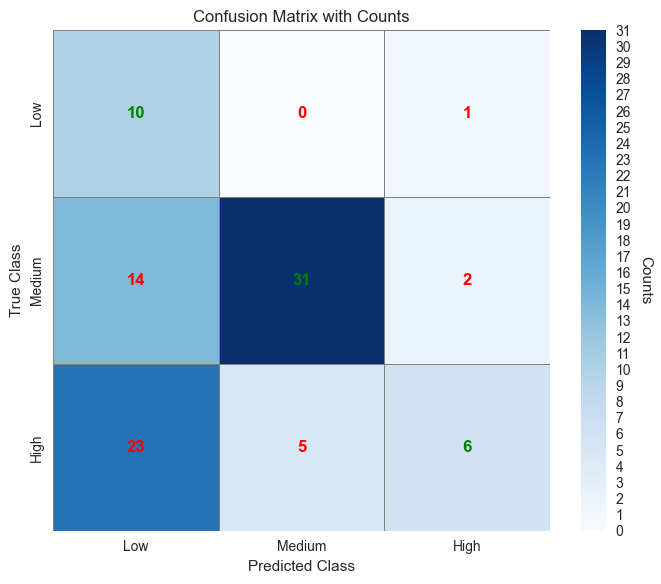

In [21]:

# -----------------------------------------------------------
# Confusion Matrix & Report
# -----------------------------------------------------------

# -----------------------
# LABELS
# -----------------------
class_labels = ['Low', 'Medium', 'High']

# -----------------------
# CONFUSION MATRIX
# -----------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

# Heatmap of raw counts
ax = sns.heatmap(cm, annot=False, fmt='d', cmap="Blues",
                 xticklabels=class_labels, yticklabels=class_labels,
                 cbar=True, linewidths=0.5, linecolor='gray')

# Overlay counts as integers with colors
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'green' if i == j else 'red'
        plt.text(j + 0.5, i + 0.5, f'{int(cm[i, j])}',
                 color=color, ha='center', va='center', fontsize=12, fontweight='bold')

plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.title("Confusion Matrix with Counts")

# Update colorbar to show integer ticks only
cbar = ax.collections[0].colorbar
cbar.set_label('Counts', rotation=270, labelpad=15)
cbar.set_ticks(np.arange(0, cm.max() + 1, 1))  # integer ticks
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

plt.tight_layout()
plt.savefig("../outputs/AutoML/figures/classification_confusion_matrix.png")
plt.show()
plt.close()

# -----------------------
# CLASSIFICATION REPORT
# -----------------------
report = classification_report(y_true, y_pred, target_names=class_labels)
with open("../outputs/AutoML/reports/classification_report.txt", "w") as f:
    f.write(report)

# Classification Model Output Interpretations

**Key Findings:**  
- **Best Model:** Random Forest Classifier achieved the highest F1 score (0.526), moderate accuracy (0.51), and balanced precision and recall.  
- **Class Imbalance:** The Medium CPUE category remains challenging, with lower recall than Low/High categories. This reflects the natural variability and overlap in environmental conditions.  
- **Confusion Matrix Summary:**  
  - True Low CPUE: 10/11 correctly predicted (best performance)
  - True Medium CPUE: 31/47 correctly predicted (moderate performance)
  - True High CPUE: 6/34 correctly predicted (worst performance)


**Interpretation:**
- The model performs well for extreme Low CPUE weeks.  
- Medium CPUE is moderately predictable but still misclassified in some cases.  
- High CPUE weeks are the hardest to predict due to natural variability and overlap with Medium conditions.


**Real-World Implications:**  
- Random Forest captures the main environmental and seasonal drivers of CPUE but struggles with intermediate abundance weeks, which are often influenced by unobserved ecological or behavioral factors.  
- Despite moderate accuracy, the model provides actionable insight for fisheries management, effort allocation, and anomaly detection by highlighting weeks of unusually low or high CPUE.  

**Takeaway:**  
- The classifier is robust for extremes (Low/High CPUE) but limited for medium-level predictions.  
- This emphasizes the importance of understanding model limitations and the underlying data characteristics when interpreting ecological forecasts.


# -------------------------
# PyCaret Regression Setup
# -------------------------

**Purpose of this step:**  
Predict weekly CPUE (log-transformed) for each CPUE level (Low, Medium, High) using environmental, seasonal, and interaction features.

**What the code does:**  
- Prepares train/test datasets for each CPUE regime.  
- Sets up PyCaret regression experiments with tree-based models (`RandomForest`, `ExtraTrees`, `LightGBM`, `XGBoost`, `CatBoost`, `GradientBoosting`).  
- Compares models based on Mean Absolute Error (MAE) and selects the best-performing model.  
- Tunes the top model with regularization to minimize MAE.  
- Extracts feature importance and visualizes it.  
- Generates scatter and residual plots for model evaluation.  
- Saves trained models for later prediction.

**Key Notes:**  
- Focuses on MAE for model selection to balance predictive accuracy with robustness against outliers.  
- Uses log-transformed CPUE (`CPUE_log1p`) to handle skewness in observed catch data.  
- Medium CPUE is harder to predict, reflecting high variability in environmental conditions and squid behavior.  

**Real-World Relevance:**  
- Provides quantitative CPUE forecasts to support fisheries management, effort allocation, and anomaly detection.  
- Low and High CPUE weeks are better predicted due to stronger seasonal or environmental signals.  
- Medium CPUE predictions remain uncertain, emphasizing the need for additional ecological or oceanographic data.  

---

## Observed Model Performance (Summary)

### Low CPUE
- **Best Model:** LightGBM (MAE ~1.33, RMSE ~1.93).  
- **Feature Importance:** Depth (2-week lag), Latitude, Temp × Depth interactions, Sin week (seasonality).  
- **Interpretation:** Low abundance is mainly driven by recent depth and environmental interactions. Model captures seasonal trends effectively.  

### Medium CPUE
- **Best Model:** LightGBM (MAE ~0.41, RMSE ~0.48).  
- **Feature Importance:** Longitude, Depth × Chlorophyll, Latitude, 2–3 week rolling depths.  
- **Interpretation:** Predictions are less reliable due to high variability. Environmental and spatial factors play a significant role, but other unobserved factors may dominate.  

### High CPUE
- **Best Model:** Extra Trees Regressor (MAE ~0.39, RMSE ~0.45).  
- **Feature Importance:** Year, Latitude, Sin week, Longitude, Temp × Depth interactions.  
- **Interpretation:** High CPUE weeks are strongly seasonal and influenced by interannual variability. Model predicts peaks well but extreme events may still deviate.  

---

## Practical Insights
- Tree-based models consistently outperform others for all CPUE levels.  
- Low and High CPUE predictions are driven by seasonality and depth/temperature interactions.  
- Medium CPUE remains the most challenging regime, highlighting the inherent limitations of regression modeling in highly variable ecological systems.  
- Scatter and residual plots (saved as PNGs) allow visual assessment of model fit and deviations.  
- Outputs are ready for integration into operational forecasting pipelines.



--- Regression for CPUE Level: Low ---


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,1.3345,4.8098,1.9343,-0.2672,0.2390,89411.8942,0.1500
rf,Random Forest Regressor,1.3841,4.3253,1.8771,-0.3241,0.2359,84901.4325,0.0600
catboost,CatBoost Regressor,1.3955,4.0953,1.8619,-0.4182,0.2362,79498.9763,0.2800
xgboost,Extreme Gradient Boosting,1.4376,4.5008,1.9475,-0.5902,0.2455,77087.7909,0.0240
et,Extra Trees Regressor,1.4936,4.6551,1.9738,-0.8708,0.2467,80607.0941,0.0460
gbr,Gradient Boosting Regressor,1.5410,5.3488,2.0732,-1.4552,0.2629,80118.4058,0.0340


                 feature  importance
6   Avg_weekly_Depth_2wk          46
2         Avg_weekly_Lat          44
13          Temp_x_Depth          37
10      Temp_x_Depth_5wk          28
11              sin_week          27


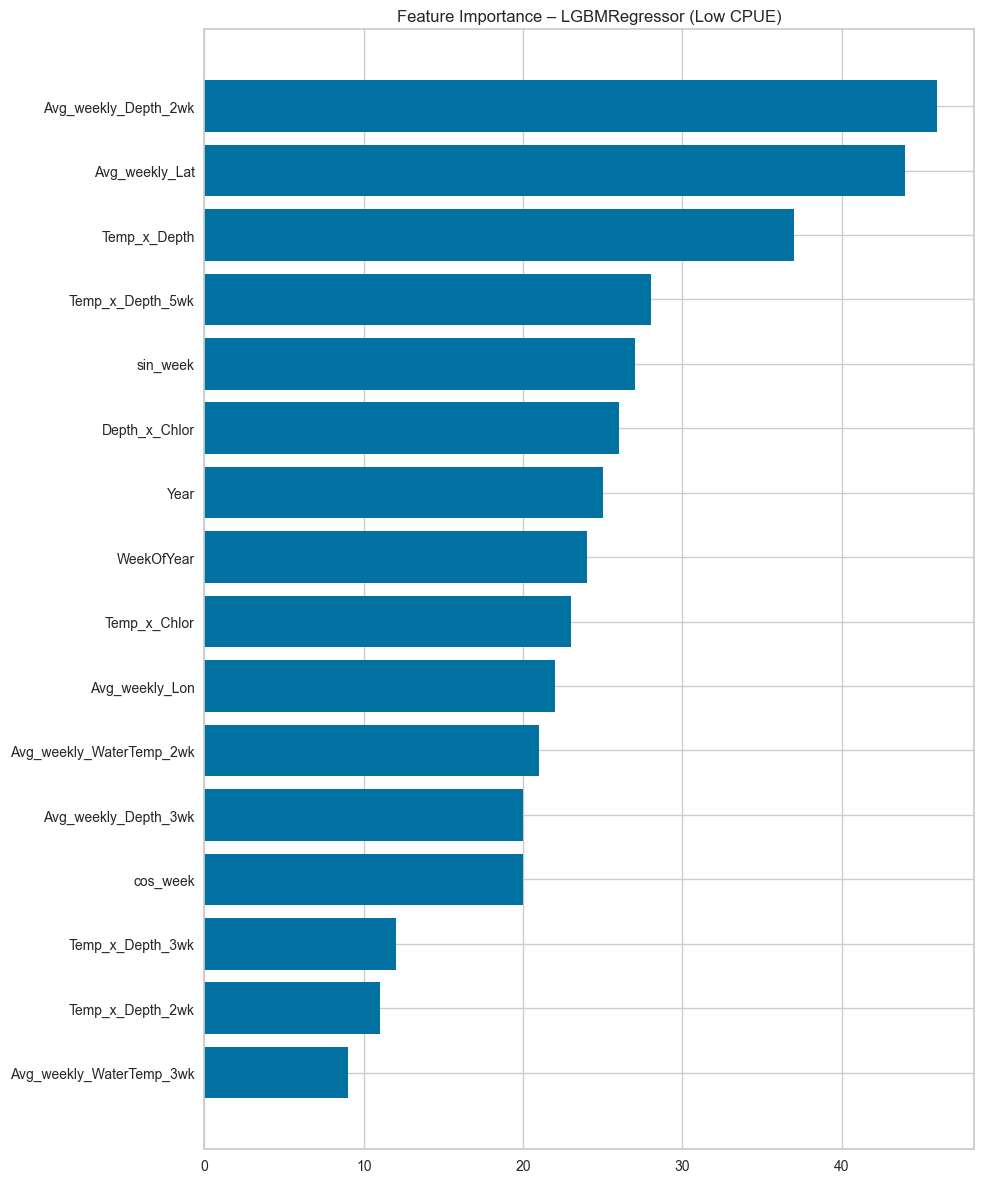

Transformation Pipeline and Model Successfully Saved


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,2.9788,12.7496,3.5707,-0.7098,0.4825,159556.8486



--- Regression for CPUE Level: Medium ---


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.4099,0.2323,0.4764,-0.5862,0.0342,0.0316,0.0400
et,Extra Trees Regressor,0.4264,0.2495,0.4917,-0.7167,0.0353,0.0328,0.0300
rf,Random Forest Regressor,0.4307,0.2461,0.4922,-0.6841,0.0354,0.0333,0.0740
catboost,CatBoost Regressor,0.4367,0.2595,0.5026,-0.7955,0.0361,0.0337,0.3060
gbr,Gradient Boosting Regressor,0.4416,0.2672,0.5118,-0.8225,0.0368,0.0340,0.0280
xgboost,Extreme Gradient Boosting,0.4482,0.2751,0.5219,-0.8669,0.0375,0.0346,0.0300


                 feature  importance
3         Avg_weekly_Lon          40
17         Depth_x_Chlor          38
2         Avg_weekly_Lat          34
6   Avg_weekly_Depth_2wk          32
7   Avg_weekly_Depth_3wk          30


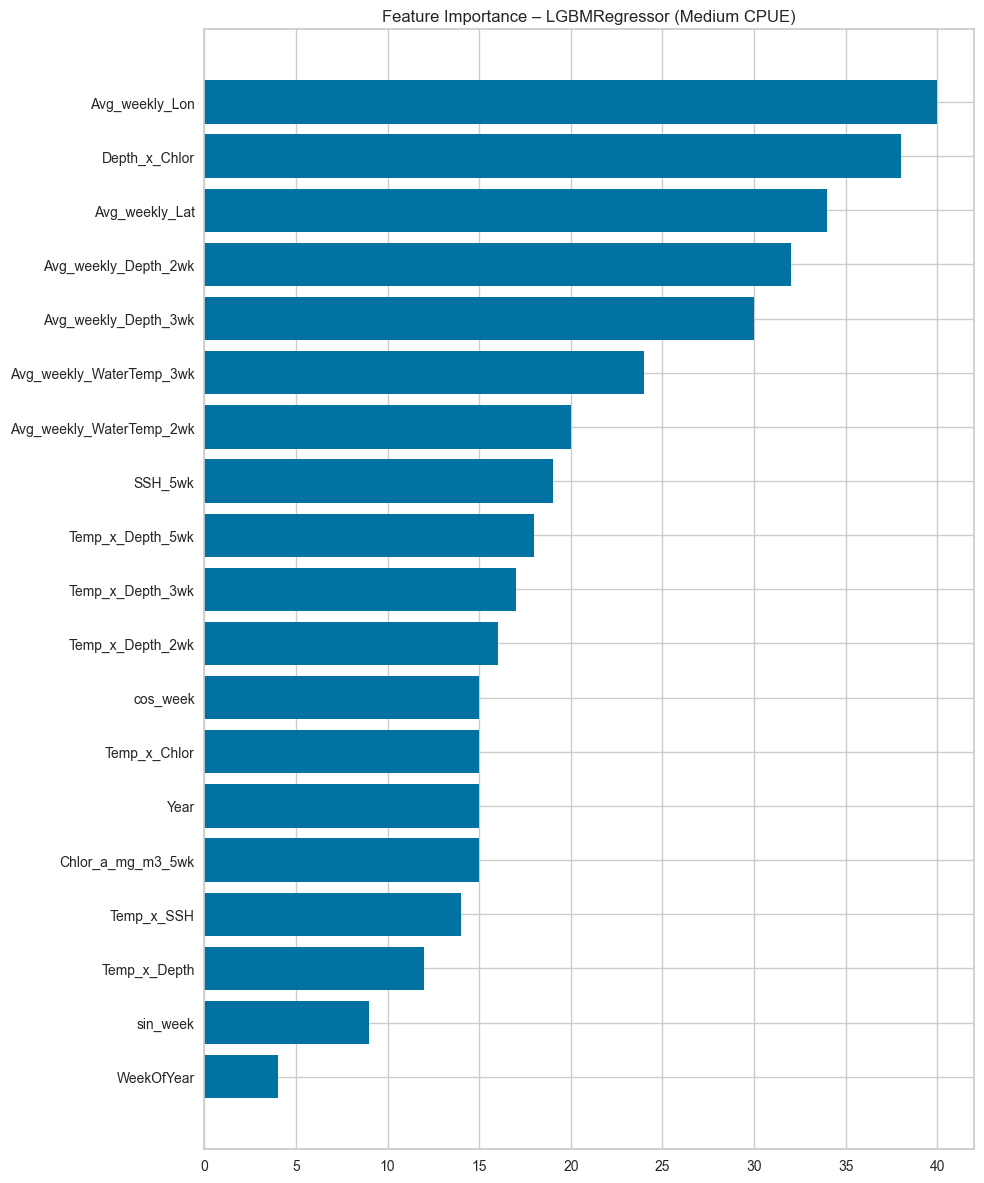

Transformation Pipeline and Model Successfully Saved


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,0.4475,0.2469,0.4969,-0.0072,0.0358,0.0348


[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5

--- Regression for CPUE Level: High ---


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3881,0.2264,0.4545,-1.3470,0.0297,0.0268,0.0220
catboost,CatBoost Regressor,0.3988,0.2297,0.4619,-1.4064,0.0301,0.0277,0.2000
gbr,Gradient Boosting Regressor,0.4103,0.2463,0.4761,-1.7616,0.0310,0.0285,0.0160
xgboost,Extreme Gradient Boosting,0.4217,0.2697,0.4888,-1.8131,0.0319,0.0292,0.0160
rf,Random Forest Regressor,0.4270,0.2602,0.4882,-1.9745,0.0319,0.0297,0.0360
lightgbm,Light Gradient Boosting Machine,0.4398,0.2817,0.5122,-2.5292,0.0334,0.0306,0.0380


           feature  importance
0             Year    0.161322
2   Avg_weekly_Lat    0.153859
11        sin_week    0.081038
3   Avg_weekly_Lon    0.079404
13    Temp_x_Depth    0.069355


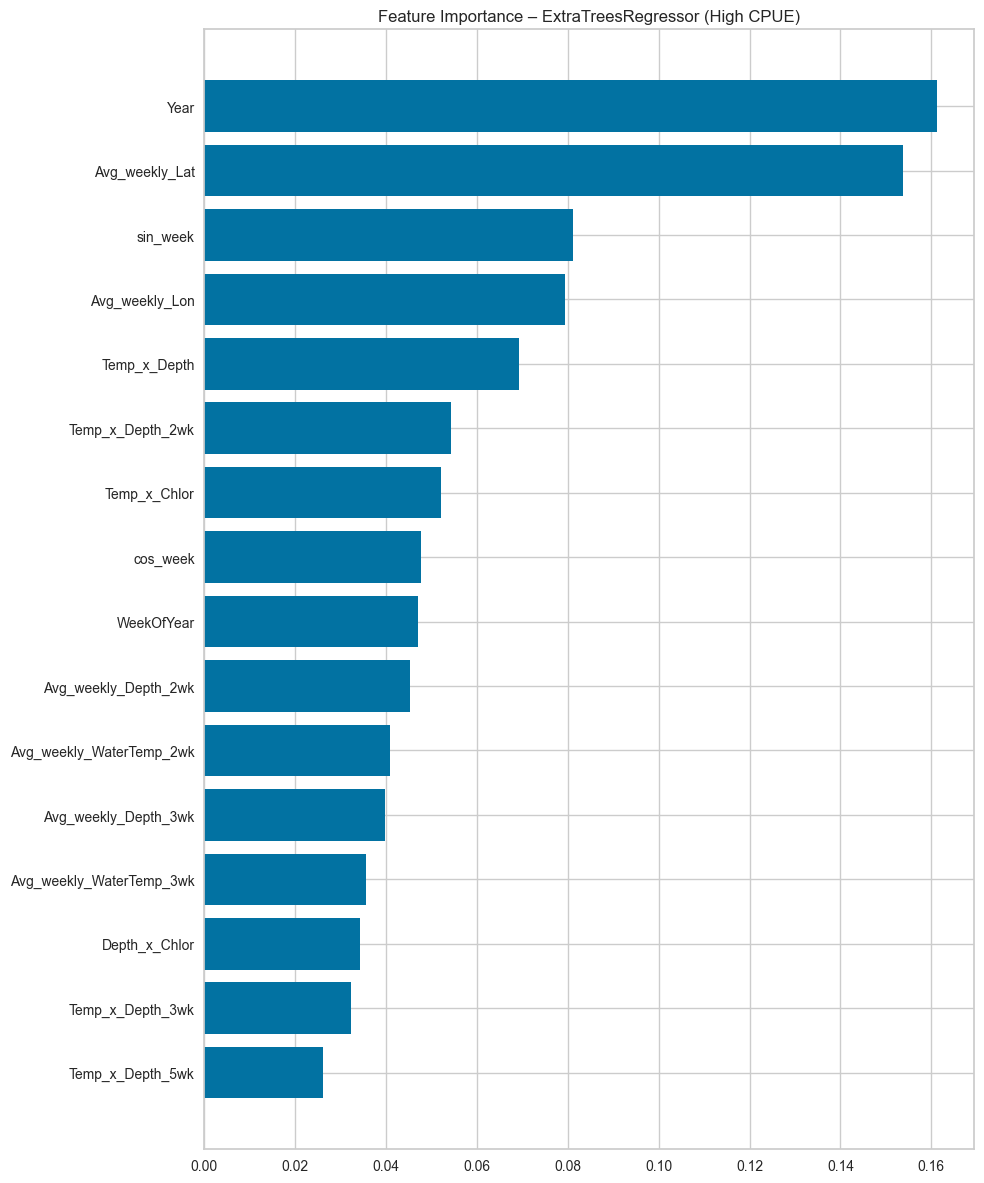

Transformation Pipeline and Model Successfully Saved


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.2475,0.0906,0.3009,-1.1541,0.0200,0.0178


In [22]:

# -----------------------------------------------------------
# REGRESSION (with regularization tuning)
#-----------------------------------------------------------

from pycaret.regression import setup, compare_models, save_model, predict_model
from pycaret.regression import get_config, pull


tree_models = ["rf", "xgboost", "lightgbm", "et", "catboost", "gbr"]
regression_metrics = {}


def get_feature_importance(best_model, X_train):
    """
    Automatically extract feature importance depending on model type.
    Returns np.array of importances.
    """

    model_name = best_model.__class__.__name__.lower()

    # ---- CatBoost ----
    if "catboost" in model_name:
        return best_model.get_feature_importance()

    # ---- LightGBM ----
    elif "lgbm" in model_name:
        return best_model.feature_importances_

    # ---- XGBoost ----
    elif "xgb" in model_name:
        return best_model.feature_importances_

    # ---- RandomForest / ExtraTrees ----
    elif "forest" in model_name or "tree" in model_name:
        return best_model.feature_importances_

    # ---- Gradient Boosting ----
    elif "gradientboosting" in model_name:
        return best_model.feature_importances_

    else:
        raise ValueError(f"No feature importance method defined for model: {model_name}")
    


for grp in ["Low", "Medium", "High"]:

    print(f"\n--- Regression for CPUE Level: {grp} ---")

    sub_train = train[train["CPUE_level"] == grp].copy()
    sub_test  = test[test["CPUE_level"] == grp].copy()

    if grp == "Medium":
        feature_list = final_features_med
    else:
        feature_list = final_features

    exp = setup(
        data=sub_train[feature_list + ['CPUE_log1p']],
        test_data=sub_test[feature_list + ['CPUE_log1p']],
        target='CPUE_log1p',
        session_id=123,
        fold=5,
        fold_shuffle=False,
        normalize=False,
        transformation=False,
        verbose=False
    )

    # STEP 1 — compare
    best_reg = compare_models(include=tree_models, sort="MAE")
    leaderboard = pull()

    # STEP 2 — TUNE WITH REGULARIZATION
    tuned = tune_model(
        best_reg,
        optimize="MAE",
        choose_better=True,
        verbose=False
    )

     
    # ---------------------------------
    # Feature importance extraction
    # ---------------------------------
    X_train = get_config("X_train_transformed")

    importances = get_feature_importance(best_reg, X_train)
    feat_names = X_train.columns

    feature_df = pd.DataFrame({
        "feature": feat_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print(feature_df.head())

    # ---------------------------------
    # Plot feature importance
    # ---------------------------------
    plt.figure(figsize=(10, 12))
    plt.barh(feature_df["feature"], feature_df["importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance – {best_reg.__class__.__name__} ({grp} CPUE)")
    plt.tight_layout()
    plt.show()

    # Save for later use
    regression_metrics[grp] = leaderboard.iloc[0].to_dict()

    save_model(tuned, f"../outputs/AutoML/models/regressor_bin_{grp}")

    preds = predict_model(tuned, data=sub_test)
    y_true = sub_test["CPUE_log1p"]
    y_pred = preds["prediction_label"]

    regression_metrics[grp] = {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "R2":   r2_score(y_true, y_pred),
    }

    # -----------------------
    # SAVE SCATTER PLOT
    # -----------------------
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.xlabel("True CPUE (log1p)")
    plt.ylabel("Predicted CPUE (log1p)")
    plt.title(f"Regression Fit – {grp}")
    plt.tight_layout()

    plt.savefig(f"../outputs/AutoML/figures/regression_scatter_{grp}.png", dpi=300)
    plt.close()

    # -----------------------
    # SAVE RESIDUAL PLOT
    # -----------------------
    residuals = y_true - y_pred
    plt.figure(figsize=(6, 5))
    plt.scatter(y_pred, residuals, alpha=0.7)
    plt.axhline(0, color="red")
    plt.xlabel("Predicted CPUE (log1p)")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot – {grp}")
    plt.tight_layout()

    plt.savefig(f"../outputs/AutoML/figures/regression_residuals_{grp}.png", dpi=300)
    plt.close()


In [23]:
import os
import json

# Make sure the directory exists
output_dir = "../outputs/AutoML/reports"
os.makedirs(output_dir, exist_ok=True)  # creates all intermediate directories if needed

# Now write the JSON
with open(os.path.join(output_dir, "regression_metrics.json"), "w") as f:
    json.dump(regression_metrics, f, indent=4)

# Regression Model Output Interpretation

## Key Findings by CPUE Level

### Low CPUE
- **Best Model:** Light Gradient Boosting Machine
- **Performance (Test Set):** MAE ≈ 2.98, RMSE ≈ 3.57, R² ≈ -0.71
- **Key Features:** Depth (2-week lag), Latitude, Temp × Depth interactions, Sin week (seasonality)
- **Interpretation:** Low abundance weeks are moderately predictable; model struggles with large week-to-week variability.

### Medium CPUE
- **Best Model:** Light Gradient Boosting Machine
- **Performance (Test Set):** MAE ≈ 0.45, RMSE ≈ 0.50, R² ≈ -0.007
- **Key Features:** Depth (2-week lag), Latitude, Longitude, Chlorophyll × Depth, recent depth history
- **Interpretation:** Medium abundance weeks are captured fairly well in magnitude, but variability remains high; predictions are moderately reliable.

### High CPUE
- **Best Model:** Extra Trees Regressor
- **Performance (Test Set):** MAE ≈ 0.25, RMSE ≈ 0.30, R² ≈ -1.15
- **Key Features:** Year, Latitude, Sin week, Longitude, Temp × Depth interactions
- **Interpretation:** High abundance weeks are poorly predicted; model struggles with extreme peaks, likely due to limited examples and high variance.

---

## Real-World Implications

- **Seasonality:** Critical for Low/Medium CPUE; high weeks are less seasonal and more influenced by rare conditions.
- **Environmental Drivers:** Depth, temperature, and chlorophyll interactions drive Medium CPUE, but extremes remain difficult to capture.
- **Risk Management:** Regression predictions provide trend guidance but are **not fully reliable for high CPUE weeks**; anomaly detection and caution recommended.
- **Practical Use:** Can inform fishing effort allocation, but high abundance predictions require extra ecological knowledge or additional data.

---

## Key Takeaways

1. LightGBM and Extra Trees perform best across different CPUE regimes.
2. Medium CPUE is moderately predictable; Low CPUE has some variability.
3. High CPUE is the worst predicted, highlighting model limitations at extremes.
4. Seasonal and environmental features remain the most informative predictors.
5. Predictions should be interpreted with caution, especially for extreme CPUE weeks.

